# Aula 4 — MNIST com rede neural (MLP)

**Objetivos**
- Entender como classificar dígitos manuscritos (0–9) com uma **rede multicamada** *(MLP)*.
- Transformar uma imagem $28 \times 28$ num **vetor de 784 valores** antes da primeira camada densa.
- Usar **cross-entropy** para classificação com várias classes (em vez do MSE do XOR).
- Acompanhar **perda no treino** e **precisão no conjunto de teste** durante o treinamento.

---

**Dependências**: `torch` e `torchvision`. No Colab já vêm pré-instalados; num ambiente local: `pip install torch torchvision matplotlib`.


## 1. O que é o MNIST?

- **MNIST**: ~70 mil imagens em escala de cinza de dígitos manuscritos, $28 \times 28$ píxeis, rótulo inteiro $\{0,\ldots,9\}$.
- **Entrada para a MLP**: achatamos a imagem para um vetor de tamanho $28 \cdot 28 = 784$. Cada píxel vira uma *feature*.
- **Saída**: para 10 classes, a rede produz **10 logits** (números reais antes do softmax).
- **`CrossEntropyLoss` no PyTorch**: espera logits e o índice da classe verdadeira; por dentro faz log-softmax e NLL ([documentação](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)). Não aplique softmax manualmente na última camada quando usar esta loss.

In [ ]:
from __future__ import annotations

import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader

def definir_semente_global(semente: int) -> None:
    random.seed(semente)
    torch.manual_seed(semente)


def criar_dispositivo() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


semente_fixa = 42
definir_semente_global(semente_fixa)
dispositivo = criar_dispositivo()
print(f"Dispositivo: {dispositivo}")

Dispositivo: cuda


## 2. Dados: `MNIST`, `Dataset` e `DataLoader`

- **`ToTensor()`**: converte a imagem para tensor com valores em $[0,1]$.
- **`Normalize((0.1307,), (0.3081,))`**: subtrai média e divide pelo desvio padrão típicos do MNIST (*z-score* por canal) — ajuda o treino a convergir de forma estável.
- **`DataLoader`** embaralha exemplos *(treino)* e agrupa-os em **lotes *(batches)***, útil porque o gradiente é calculado sobre o lote (SGD por mini-batch).

In [ ]:
diretorio_dados = "./mnist_data"
tamanho_lote_treino = 64
tamanho_lote_teste = 1000

transformacoes_mnist = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,)),
])

conjunto_treino = torchvision.datasets.MNIST(
    root=diretorio_dados,
    train=True,
    download=True,
    transform=transformacoes_mnist,
)
conjunto_teste = torchvision.datasets.MNIST(
    root=diretorio_dados,
    train=False,
    download=True,
    transform=transformacoes_mnist,
)

carregador_treino = DataLoader(
    dataset=conjunto_treino,
    batch_size=tamanho_lote_treino,
    shuffle=True,
)
carregador_teste = DataLoader(
    dataset=conjunto_teste,
    batch_size=tamanho_lote_teste,
    shuffle=False,
)

tam_img = conjunto_treino[0][0].shape
print(f"Forma do tensor por imagem: {tam_img}  (= 1 canal × 28 × 28)")
print(f"Treino: {len(conjunto_treino)} imagens | Teste: {len(conjunto_teste)} imagens")

Forma do tensor por imagem: torch.Size([1, 28, 28])  (= 1 canal × 28 × 28)
Treino: 60000 imagens | Teste: 10000 imagens


## 3. Arquitetura: MLP (achatar → linear → não-linearidade → linear)

- **`Flatten`**: $\mathbb{R}^{1 \times 28 \times 28} \to \mathbb{R}^{784}$.
- **Camadas densas**: $784 \to 128$ com ReLU e depois $128 \to 10$ logits *(uma por dígito)*.
- **Por que ReLU aqui e não sigmoide?** Para redes mais profundas, ReLU costuma evitar o *vanishing gradient* em comparação com sigmóide apenas (no XOR demos sigmóide de propósito didático).

In [ ]:
dim_entrada_plana = int(28 * 28)
dim_oculta = 128
num_classes = 10


def criar_modelo_multiclasse() -> nn.Sequential:
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(dim_entrada_plana, dim_oculta),
        nn.ReLU(),
        nn.Linear(dim_oculta, num_classes),
    )


# .to() manda os dados para o dispositivo, o ideal é manter todos os dados no mesmo dispositivo, seja ele CPU, GPU etc
modelo = criar_modelo_multiclasse().to(dispositivo)
print(modelo)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Otimização: `CrossEntropyLoss` + `SGD`

**`CrossEntropyLoss`**: penaliza probabilidade baixa na classe correta. É a escolha padrão para classificação com rótulos inteiros.

No laço:
1. `zero_grad()` zera gradientes antigos;
2. `backward()` propaga $\partial L / \partial w$;
3. `step()` aplica $\; w \gets w - \eta \frac{\partial L}{\partial w}\;$ (mini-batch SGD).

In [ ]:
taxa_aprendizado = 0.01
momentum_sgd = 0.9

criterio_ce = nn.CrossEntropyLoss()
otimizador = torch.optim.SGD(
    modelo.parameters(),
    lr=taxa_aprendizado,
    momentum=momentum_sgd,
)


@torch.no_grad()
def avaliar_conjunto(modelo_ml: nn.Module, loader: DataLoader) -> tuple[float, float]:
    modelo_ml.eval()
    total_perda = 0.0
    total_amostras = 0
    total_corretos = 0
    for lotes_entrada, rotulos_verdade in loader:
        lotes_entrada = lotes_entrada.to(dispositivo)
        rotulos_verdade = rotulos_verdade.to(dispositivo)
        logits_pred = modelo_ml(lotes_entrada)
        lote_perda = criterio_ce(logits_pred, rotulos_verdade)
        total_perda += lote_perda.item() * lotes_entrada.size(0)
        predicoes = logits_pred.argmax(dim=1)
        total_corretos += int((predicoes == rotulos_verdade).sum().item())
        total_amostras += int(lotes_entrada.size(0))
    media_perda = total_perda / max(total_amostras, 1)
    proporcao_certas = total_corretos / max(total_amostras, 1)
    return media_perda, proporcao_certas

In [ ]:
num_epocas = 5
historico_perda_treino: list[float] = []
historico_precisao_teste: list[float] = []

for indice_epoca in range(num_epocas):
    modelo.train()
    soma_perda_epoca = 0.0
    contagem_lotes = 0

    for lotes_entrada, rotulos_verdade in carregador_treino:
        lotes_entrada = lotes_entrada.to(dispositivo)
        rotulos_verdade = rotulos_verdade.to(dispositivo)

        otimizador.zero_grad()
        logits_pred = modelo(lotes_entrada)
        loss = criterio_ce(logits_pred, rotulos_verdade)
        loss.backward()
        otimizador.step()

        soma_perda_epoca += loss.item()
        contagem_lotes += 1

    perda_media_treino = soma_perda_epoca / max(contagem_lotes, 1)
    perda_teste, precisao_teste = avaliar_conjunto(modelo_ml=modelo, loader=carregador_teste)
    historico_perda_treino.append(perda_media_treino)
    historico_precisao_teste.append(precisao_teste)

    print(
        f"Época {indice_epoca + 1:2d}/{num_epocas} | "
        f"Loss treino (média nos lotes): {perda_media_treino:.4f} | "
        f"Loss teste: {perda_teste:.4f} | Precisão teste: {100.0 * precisao_teste:.2f}%"
    )

Época  1/5 | Loss treino (média nos lotes): 0.2781 | Loss teste: 0.1387 | Precisão teste: 95.83%
Época  2/5 | Loss treino (média nos lotes): 0.1165 | Loss teste: 0.1010 | Precisão teste: 97.02%
Época  3/5 | Loss treino (média nos lotes): 0.0793 | Loss teste: 0.0889 | Precisão teste: 97.23%
Época  4/5 | Loss treino (média nos lotes): 0.0615 | Loss teste: 0.0769 | Precisão teste: 97.65%
Época  5/5 | Loss treino (média nos lotes): 0.0474 | Loss teste: 0.0773 | Precisão teste: 97.60%


## 5. Curvas de treino vs. generalização

**Perda no treino** tende a cair sempre que o otimizador encaixa o conjunto usado nos gradientes. **Precisão no teste** indica como o modelo se comporta em dados *novos*: se treino melhora mas teste estagna ou piora, pode ser **overfitting** (vale experimentar menos épocas, mais dados, dropout, etc.).

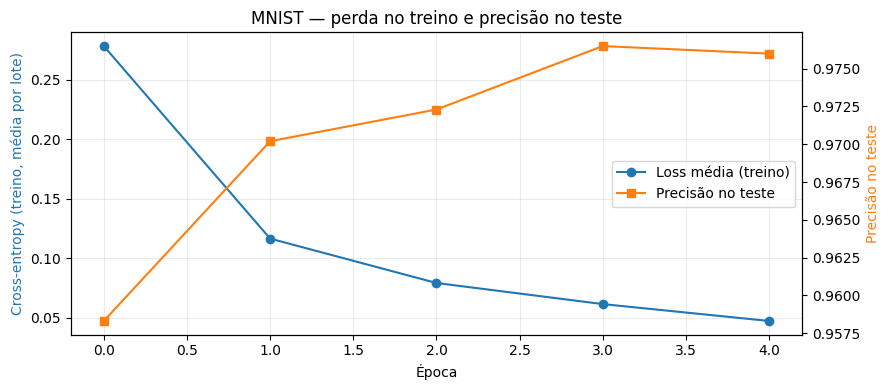

In [ ]:
indices_epoca = list(range(len(historico_perda_treino)))

fig, eixo_esq = plt.subplots(figsize=(9, 4))
eixo_dir = eixo_esq.twinx()

linha_loss = eixo_esq.plot(
    indices_epoca,
    historico_perda_treino,
    color="tab:blue",
    marker="o",
    linewidth=1.5,
    label="Loss média (treino)",
)[0]

linha_acc = eixo_dir.plot(
    indices_epoca,
    historico_precisao_teste,
    color="tab:orange",
    marker="s",
    linewidth=1.5,
    label="Precisão no teste",
)[0]

eixo_esq.set_xlabel("Época")
eixo_esq.set_ylabel("Cross-entropy (treino, média por lote)", color="tab:blue")
eixo_dir.set_ylabel("Precisão no teste", color="tab:orange")
eixo_esq.set_title("MNIST — perda no treino e precisão no teste")

eixo_esq.legend(handles=[linha_loss, linha_acc], loc="center right")
eixo_esq.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Inspeção: imagens vs. classe prevista vs. probabilidade

Softmax $\sigma(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$ converte logits em probabilidades sobre as 10 classes. Abaixo invertemos a normalização apenas para visualizar os píxeis de forma próxima do original.

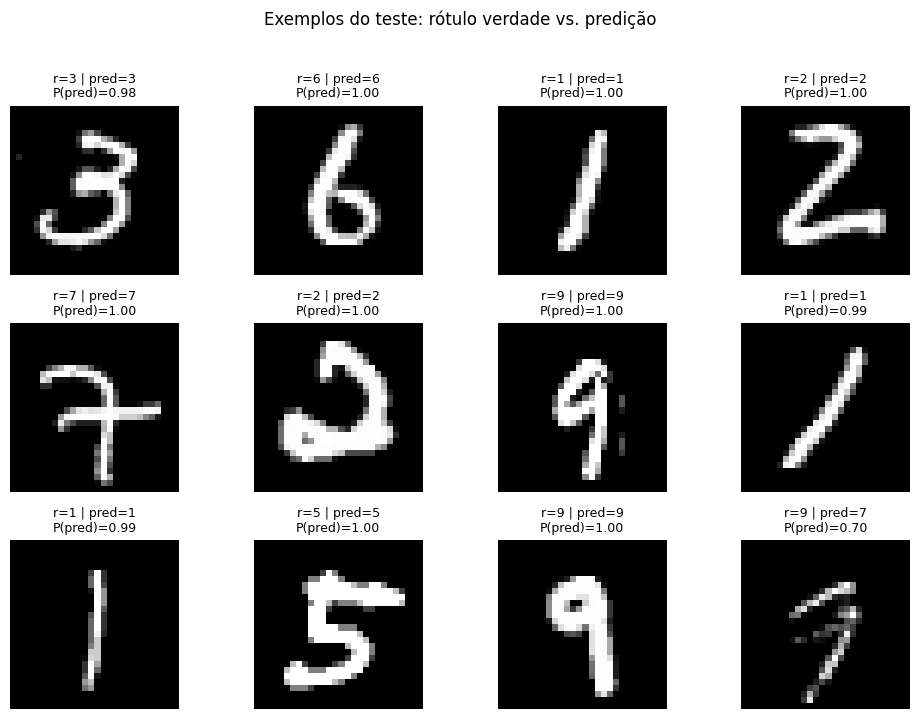

In [ ]:
media_mnist = 0.1307
desvio_mnist = 0.3081


def tensor_para_visual(tensor_normalizado: torch.Tensor) -> torch.Tensor:
    return tensor_normalizado * desvio_mnist + media_mnist


num_mostrar = 12
modelo.eval()
indices_aleatorios = torch.randint(low=0, high=len(conjunto_teste), size=(num_mostrar,))

fig, quadrados = plt.subplots(nrows=3, ncols=4, figsize=(10, 7))
with torch.no_grad():
    for indice_quadro, quadro in enumerate(quadrados.flat):
        imagem_original, rotulo_v = conjunto_teste[int(indices_aleatorios[indice_quadro])]
        imagem_quadro = imagem_original.unsqueeze(0).to(dispositivo)
        logits = modelo(imagem_quadro)
        probs = logits.softmax(dim=1)[0]
        classe_predita = int(probs.argmax().item())

        quadro.imshow(tensor_para_visual(imagem_original[0]).cpu().numpy(), cmap="gray", vmin=0.0, vmax=1.0)
        quadro.set_title(
            f"r={rotulo_v} | pred={classe_predita}\nP(pred)={probs[classe_predita].item():.2f}",
            fontsize=9,
        )
        quadro.axis("off")

plt.suptitle("Exemplos do teste: rótulo verdade vs. predição", y=1.02)
plt.tight_layout()
plt.show()

## 7. Exercícios sugeridos

1. Aumente `num_epocas` ou `dim_oculta` e observe o efeito na curva de teste.
2. Remova `Normalize` e veja se o treino fica mais lento ou instável.
3. *(Avançado)* Substitua a MLP por uma **CNN** pequena (`Conv2d` + `MaxPool2d`) e compare precisão com o mesmo número de épocas.